In [1]:
# Install Libraries
!pip install -q ultralytics roboflow opencv-python pandas matplotlib seaborn tqdm pyyaml


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 49.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 58.2 MB/s eta 0:00:00


In [2]:
# Import Libraries
import os
import glob
import shutil
import warnings
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

from PIL import Image
from tqdm import tqdm
from ultralytics import YOLO
from roboflow import Roboflow
from IPython.display import Video, display

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
# Configuration
# All paths below are anchored on this single ROOT, so every later cell
# (training, plots, video inference) agrees on where files actually live.
ROOT = Path("/content").resolve() if Path("/content").exists() else Path.cwd()

WORKSPACE = "detection-system"
PROJECT_SLUG = "humps-bumps-potholes-detection"
PROJECT_VERSION = 8

BASE_MODEL = "yolov8n.pt"          # stock pretrained weights (downloaded by ultralytics)
CUSTOM_MODEL_PATH = "best.pt"       # your already-trained model
TEST_VIDEO = "test.mp4"

OUTPUT_DIR = ROOT / "results"
TRAIN_PROJECT = OUTPUT_DIR / "training"
TRAIN_NAME = "pothole_training"
DATA_YAML = Path("data.yaml")        # overwritten once the dataset is downloaded below

EPOCHS = 40
IMG_SIZE = 640
BATCH_SIZE = 16

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TRAIN_PROJECT.mkdir(parents=True, exist_ok=True)

print("Root directory:", ROOT)
print("Configuration loaded")


Root directory: /content
Configuration loaded


In [4]:
# Dataset Download (Roboflow)
# Replace with your own API key if this one has expired/been rotated.
api_key = "IuIHLqh6LQAaMJaHCWgP"

rf = Roboflow(api_key=api_key)
project = rf.workspace(WORKSPACE).project(PROJECT_SLUG)
version = project.version(PROJECT_VERSION)

dataset = version.download("yolov8")

# Path to data.yaml, now that the dataset actually exists on disk
DATA_YAML = Path(dataset.location) / "data.yaml"

print("Dataset YAML:", DATA_YAML)


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Humps/Bumps-&-Potholes-Detection-8 in yolov8:: 100%|██████████| 6498/6498 [00:10<00:00, 630.51it/s] 


Dataset YAML: /content/Humps/Bumps-&-Potholes-Detection-8/data.yaml


In [5]:
# Dataset Verification
dataset_root = Path(DATA_YAML).parent
required_items = ["train", "valid", "test", "data.yaml"]

print("Dataset root:", dataset_root)
for item in required_items:
    path = dataset_root / item
    status = "FOUND" if path.exists() else "MISSING"
    print(f"{item}: {status}")

class_names = []
try:
    with open(DATA_YAML, "r", encoding="utf-8") as f:
        data_cfg = yaml.safe_load(f)
    names = data_cfg.get("names", [])
    class_names = list(names.values()) if isinstance(names, dict) else list(names)
    print("Classes:", class_names)
except Exception as exc:
    print("Could not read class names:", exc)

# best.pt was trained with classes ["Pothole", "Speed Bump"]. If data.yaml's
# classes don't match (different names, order, or count), validation metrics
# for the custom model below will be meaningless, so check this before continuing.
expected_custom_classes = ["Pothole", "Speed Bump"]
if class_names and class_names != expected_custom_classes:
    print(
        "WARNING: data.yaml classes", class_names,
        "do not match the classes best.pt was trained on", expected_custom_classes,
        "- double-check you're using the matching dataset version.",
    )


Dataset root: /content/Humps/Bumps-&-Potholes-Detection-8
train: FOUND
valid: FOUND
test: FOUND
data.yaml: FOUND
Classes: ['Pothole', 'Speed Bump']


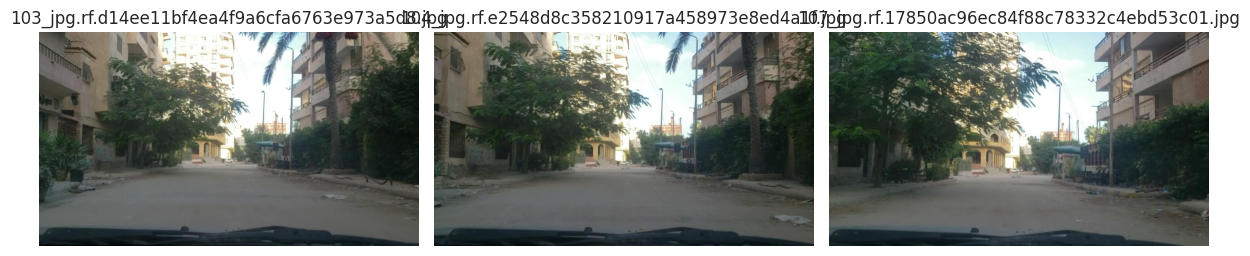

In [7]:
# Dataset Visualization
def show_sample_images(split="train", max_images=3):
    image_dir = dataset_root / split / "images"
    images = sorted(
        list(image_dir.glob("*.jpg"))
        + list(image_dir.glob("*.jpeg"))
        + list(image_dir.glob("*.png"))
    )[:max_images]

    if not images:
        print(f"No images found in {image_dir}")
        return

    cols = 3
    rows = int(np.ceil(len(images) / cols))
    plt.figure(figsize=(12, 4 * rows))

    for i, image_path in enumerate(images, 1):
        img = Image.open(image_path)
        plt.subplot(rows, cols, i)
        plt.imshow(img)
        plt.title(image_path.name)
        plt.axis("off")

    plt.tight_layout()
    plt.show()


show_sample_images("train")


In [8]:
# Model Loading
# At this stage we only load the two models that already exist on disk:
#   - best.pt        -> your trained custom model (2 classes: Pothole, Speed Bump)
#   - yolov8n.pt      -> stock, pretrained, NOT fine-tuned on this dataset
# The fine-tuned YOLOv8n (trained later in this notebook) is loaded separately
# right after training finishes, and is added to the comparison at that point.
#
# If best.pt is not already in the working directory, upload it via the Colab
# file browser (left sidebar) or files.upload() below before continuing.

if not Path(CUSTOM_MODEL_PATH).exists():
    try:
        from google.colab import files
        print("best.pt not found in the working directory. Upload it now.")
        files.upload()
    except Exception:
        print(f"Place your custom model at {CUSTOM_MODEL_PATH} before running validation.")

custom_model = YOLO(CUSTOM_MODEL_PATH) if Path(CUSTOM_MODEL_PATH).exists() else None
pretrained_model = YOLO(BASE_MODEL)   # downloads stock COCO weights if not already cached

print("Custom model (best.pt):", "loaded" if custom_model else "NOT loaded")
if custom_model:
    print("Custom model classes:", custom_model.names)
print("Pretrained YOLOv8n (stock):", "loaded")


best.pt not found in the working directory. Upload it now.


Saving best.pt to best.pt
Custom model (best.pt): loaded
Custom model classes: {0: 'Pothole', 1: 'Speed Bump'}
Pretrained YOLOv8n (stock): loaded


In [9]:
# Model Summary
if custom_model:
    print("Custom model (best.pt) summary")
    custom_model.info()

print("\nPretrained YOLOv8n (stock) summary")
pretrained_model.info()


Custom model (best.pt) summary
Model summary: 129 layers, 3,011,238 parameters, 0 gradients, 8.2 GFLOPs

Pretrained YOLOv8n (stock) summary
YOLOv8n summary: 129 layers, 3,157,200 parameters, 0 gradients, 8.9 GFLOPs


(129, 3157200, 0, 8.8575488)

In [10]:
# Custom Model Validation (best.pt)
custom_results = None

if custom_model:
    custom_results = custom_model.val(data=str(DATA_YAML), imgsz=IMG_SIZE)
    print("Custom model (best.pt) validation completed")
else:
    print("Custom model was not loaded; skipping custom validation.")


Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2128.2±758.7 MB/s, size: 569.8 KB)
val: Scanning /content/Humps/Bumps-&-Potholes-Detection-8/valid/labels... 475 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 475/475 2.2Kit/s 0.2s
val: New cache created: /content/Humps/Bumps-&-Potholes-Detection-8/valid/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 30/30 1.5it/s 20.6s
                   all        475        978      0.633      0.561      0.591      0.248
               Pothole        327        825      0.685      0.387      0.465      0.175
            Speed Bump        152        153      0.581      0.735      0.717      0.321
Speed: 2.0ms preprocess, 4.3ms inference, 0.0ms loss, 2.2ms postprocess per image
Results saved to /content/runs/detec

In [11]:
# Pretrained YOLOv8n Validation (stock, no fine-tuning)
# Note: this model has never seen potholes/speed bumps, so very low scores
# here are expected. It's a baseline, not a fair fight against best.pt.
pretrained_results = pretrained_model.val(data=str(DATA_YAML), imgsz=IMG_SIZE)
print("Pretrained YOLOv8n validation completed")


Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2667.6±1068.8 MB/s, size: 666.2 KB)
val: Scanning /content/Humps/Bumps-&-Potholes-Detection-8/valid/labels.cache... 475 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 475/475 99.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 30/30 1.5it/s 20.5s
                   all        475        978    0.00237   0.000606   1.41e-05   5.04e-06
                person        327        825    0.00475    0.00121   2.82e-05   1.01e-05
               bicycle        152        153          0          0          0          0
Speed: 1.8ms preprocess, 4.3ms inference, 0.0ms loss, 2.8ms postprocess per image
Results saved to /content/runs/detect/val-2
Pretrained YOLOv8n validation completed


In [12]:
# Metrics Extraction
def extract_metrics(results, model_name):
    if results is None:
        return None

    inference_ms = float(results.speed.get("inference", 0))
    fps = 1000 / inference_ms if inference_ms > 0 else 0

    return {
        "Model": model_name,
        "Precision": float(results.results_dict.get("metrics/precision(B)", results.box.mp)),
        "Recall": float(results.results_dict.get("metrics/recall(B)", results.box.mr)),
        "mAP50": float(results.results_dict.get("metrics/mAP50(B)", results.box.map50)),
        "mAP50-95": float(results.results_dict.get("metrics/mAP50-95(B)", results.box.map)),
        "Inference ms": inference_ms,
        "FPS": fps,
    }


metrics_rows = [
    row for row in [
        extract_metrics(custom_results, "Custom Model (best.pt)"),
        extract_metrics(pretrained_results, "YOLOv8n (pretrained)"),
    ]
    if row is not None
]

metrics_rows


[{'Model': 'Custom Model (best.pt)',
  'Precision': 0.6329637837886894,
  'Recall': 0.5608069490094574,
  'mAP50': 0.5907213893743206,
  'mAP50-95': 0.24764166928246403,
  'Inference ms': 4.315181189473678,
  'FPS': 231.73997941022031},
 {'Model': 'YOLOv8n (pretrained)',
  'Precision': 0.0023747811985382603,
  'Recall': 0.0006060606060606061,
  'mAP50': 1.4124293785310734e-05,
  'mAP50-95': 5.0364287755621e-06,
  'Inference ms': 4.256912793684214,
  'FPS': 234.91202391640581}]

In [13]:
# Comparison DataFrame
# This starts with the two models we can evaluate right away (best.pt and the
# stock pretrained model). The fine-tuned YOLOv8n row is appended to this same
# dataframe later, right after its training/validation cells run.
comparison_df = pd.DataFrame(metrics_rows).round(4)
comparison_csv = OUTPUT_DIR / "model_comparison.csv"
comparison_df.to_csv(comparison_csv, index=False)

display(comparison_df)
print("Saved:", comparison_csv)


,Model,Precision,Recall,mAP50,mAP50-95,Inference ms,FPS
0,Custom Model (best.pt),0.6330,0.5608,0.5907,0.2476,4.3152,231.740
1,YOLOv8n (pretrained),0.0024,0.0006,0.0000,0.0000,4.2569,234.912


Saved: /content/results/model_comparison.csv


# Fine-Tuning YOLOv8n on This Dataset

The cells below train a fresh YOLOv8n model on the pothole/speed-bump dataset, so it can be
compared against `best.pt` on equal terms (same data, same task). The result of this
training run is added to `comparison_df` further down, so the final ranking includes all
three models: `best.pt`, stock pretrained YOLOv8n, and this fine-tuned YOLOv8n.


In [14]:
# Training Function (Resume Supported)
def train_model(epochs=EPOCHS, resume=True):
    last_checkpoint = TRAIN_PROJECT / TRAIN_NAME / "weights" / "last.pt"

    if resume and last_checkpoint.exists():
        print("Resuming training from:", last_checkpoint)
        model = YOLO(str(last_checkpoint))
        return model.train(resume=True)

    print("Starting new training from:", BASE_MODEL)
    model = YOLO(BASE_MODEL)
    return model.train(
        data=str(DATA_YAML),
        epochs=epochs,
        imgsz=IMG_SIZE,
        batch=BATCH_SIZE,
        project=str(TRAIN_PROJECT),
        name=TRAIN_NAME,
        save=True,
        save_period=5,
        pretrained=True,
        verbose=True,
    )


In [15]:
# Train Model
training_results = train_model()
print("Training complete")


Starting new training from: yolov8n.pt
Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Humps/Bumps-&-Potholes-Detection-8/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=pothole_training, nbs=64, nms=False, op

In [16]:
# Load Training History
history_path = TRAIN_PROJECT / TRAIN_NAME / "results.csv"

if history_path.exists():
    history = pd.read_csv(history_path)
    display(history.head())
    print("History rows:", len(history))
else:
    history = pd.DataFrame()
    print("Training history not found:", history_path)


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,149.989,2.49421,3.62808,1.64363,0.27515,0.35493,0.19781,0.05830,2.58245,3.29087,1.70193,0.000552,0.000552,0.000552
1,2,287.480,2.41664,2.68438,1.59526,0.43607,0.35888,0.30950,0.10525,2.47314,2.59911,1.59496,0.001080,0.001080,0.001080
2,3,422.535,2.38957,2.37948,1.61435,0.41045,0.22046,0.19441,0.06928,2.57922,2.69303,1.67698,0.001581,0.001581,0.001581
3,4,550.218,2.39553,2.25197,1.60027,0.43041,0.33792,0.31877,0.09851,2.46001,2.31271,1.60188,0.001543,0.001543,0.001543
4,5,677.532,2.31942,2.15457,1.59172,0.38406,0.38169,0.33275,0.11582,2.42878,2.11058,1.52612,0.001502,0.001502,0.001502


History rows: 40


In [17]:
# Print Final Training Metrics
if history.empty:
    print("No training history available.")
else:
    last = history.iloc[-1]
    metric_cols = [
        "metrics/precision(B)",
        "metrics/recall(B)",
        "metrics/mAP50(B)",
        "metrics/mAP50-95(B)",
    ]

    print("Final Training Metrics")
    for col in metric_cols:
        if col in last:
            print(f"{col}: {last[col]:.4f}")


Final Training Metrics
metrics/precision(B): 0.7827
metrics/recall(B): 0.6912
metrics/mAP50(B): 0.7364
metrics/mAP50-95(B): 0.3528


In [18]:
# Save Training History
summary_path = OUTPUT_DIR / "final_training_metrics.csv"

if not history.empty:
    final_metrics = history.tail(1).copy()
    final_metrics.to_csv(summary_path, index=False)
    print("Saved:", summary_path)


Saved: /content/results/final_training_metrics.csv


In [19]:
# Load Fine-Tuned Model and Add It to the Comparison
# This is the step that was missing before: the freshly trained YOLOv8n model
# is loaded, validated with the exact same data/imgsz as the other two models,
# and its metrics are appended to comparison_df so it's included in every
# table, ranking, and plot from this point on.
checkpoint_dir = TRAIN_PROJECT / TRAIN_NAME / "weights"
checkpoints = sorted(checkpoint_dir.glob("*.pt")) if checkpoint_dir.exists() else []

for checkpoint in checkpoints:
    print(checkpoint)

finetuned_best_path = checkpoint_dir / "best.pt"
finetuned_model = YOLO(str(finetuned_best_path)) if finetuned_best_path.exists() else None

if finetuned_model:
    finetuned_results = finetuned_model.val(data=str(DATA_YAML), imgsz=IMG_SIZE)
    finetuned_row = extract_metrics(finetuned_results, "YOLOv8n (fine-tuned)")

    comparison_df = pd.concat(
        [comparison_df, pd.DataFrame([finetuned_row])], ignore_index=True
    ).round(4)
    comparison_df.to_csv(comparison_csv, index=False)

    print("Fine-tuned model added to comparison_df")
else:
    finetuned_results = None
    print("Fine-tuned checkpoint not found; comparison_df left unchanged.")

display(comparison_df)


/content/results/training/pothole_training/weights/best.pt
/content/results/training/pothole_training/weights/epoch0.pt
/content/results/training/pothole_training/weights/epoch10.pt
/content/results/training/pothole_training/weights/epoch15.pt
/content/results/training/pothole_training/weights/epoch20.pt
/content/results/training/pothole_training/weights/epoch25.pt
/content/results/training/pothole_training/weights/epoch30.pt
/content/results/training/pothole_training/weights/epoch35.pt
/content/results/training/pothole_training/weights/epoch5.pt
/content/results/training/pothole_training/weights/last.pt
Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 5169.0±995.3 MB/s, size: 767.7 KB)
val: Scanning /content/Humps/Bumps-&-Potholes-Detection-8/valid/labels.cache... 475 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 475/

,Model,Precision,Recall,mAP50,mAP50-95,Inference ms,FPS
0,Custom Model (best.pt),0.6330,0.5608,0.5907,0.2476,4.3152,231.740
1,YOLOv8n (pretrained),0.0024,0.0006,0.0000,0.0000,4.2569,234.912
2,YOLOv8n (fine-tuned),0.8028,0.6802,0.7342,0.3528,4.2091,237.580


In [20]:
# Best Model Selection (by mAP50-95, across all available models)
if comparison_df.empty:
    best_model_name = None
    print("No validation metrics available.")
else:
    best_idx = comparison_df["mAP50-95"].idxmax()
    best_row = comparison_df.loc[best_idx]
    best_model_name = best_row["Model"]

    print("Best model:", best_model_name)
    print(best_row)


Best model: YOLOv8n (fine-tuned)
Model           YOLOv8n (fine-tuned)
Precision                     0.8028
Recall                        0.6802
mAP50                         0.7342
mAP50-95                      0.3528
Inference ms                  4.2091
FPS                           237.58
Name: 2, dtype: object


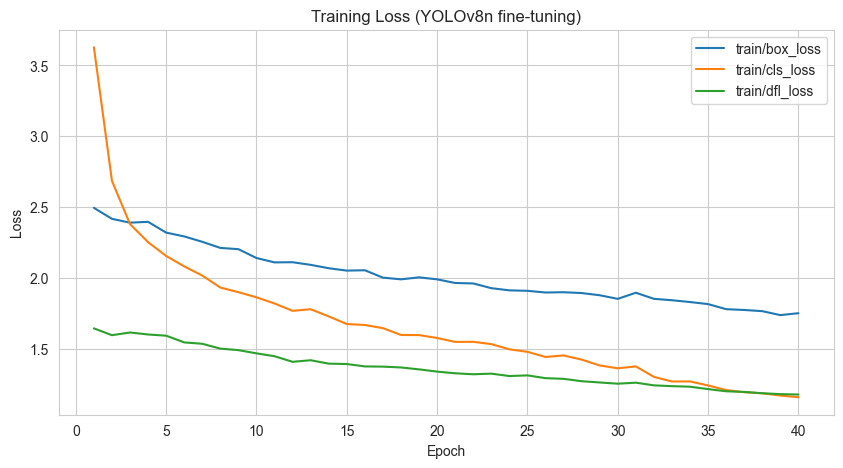

In [21]:
# Training Loss Graphs
loss_cols = ["train/box_loss", "train/cls_loss", "train/dfl_loss"]

if history.empty:
    print("No history available.")
else:
    plt.figure(figsize=(10, 5))
    for col in loss_cols:
        if col in history:
            plt.plot(history["epoch"], history[col], label=col)

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Loss (YOLOv8n fine-tuning)")
    plt.legend()
    plt.grid(True)
    plt.show()


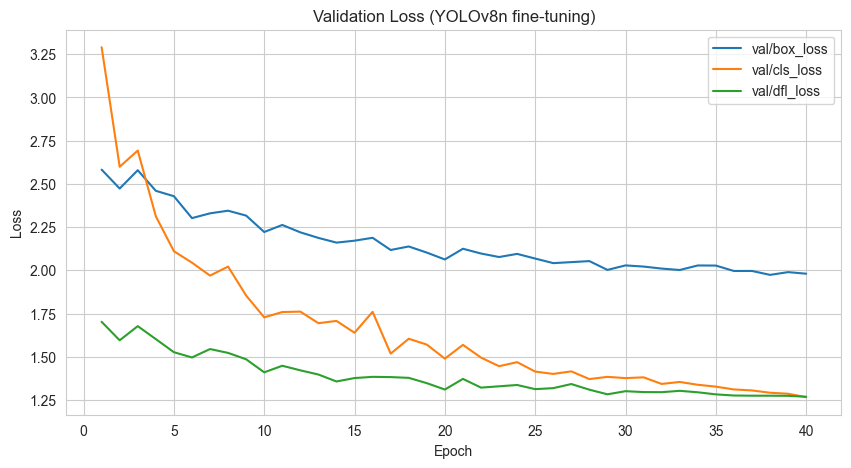

In [22]:
# Validation Loss Graphs
val_loss_cols = ["val/box_loss", "val/cls_loss", "val/dfl_loss"]

if history.empty:
    print("No history available.")
else:
    plt.figure(figsize=(10, 5))
    for col in val_loss_cols:
        if col in history:
            plt.plot(history["epoch"], history[col], label=col)

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Validation Loss (YOLOv8n fine-tuning)")
    plt.legend()
    plt.grid(True)
    plt.show()


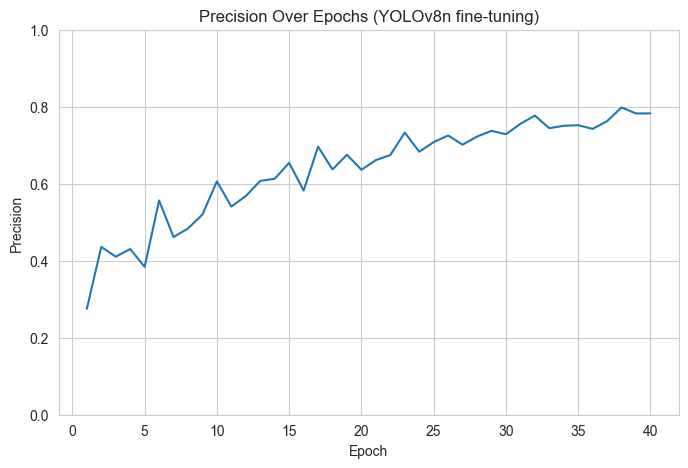

In [23]:
# Precision Curve
if history.empty or "metrics/precision(B)" not in history:
    print("Precision history is unavailable.")
else:
    plt.figure(figsize=(8, 5))
    plt.plot(history["epoch"], history["metrics/precision(B)"], color="tab:blue")
    plt.xlabel("Epoch")
    plt.ylabel("Precision")
    plt.title("Precision Over Epochs (YOLOv8n fine-tuning)")
    plt.ylim(0, 1)
    plt.grid(True)
    plt.show()


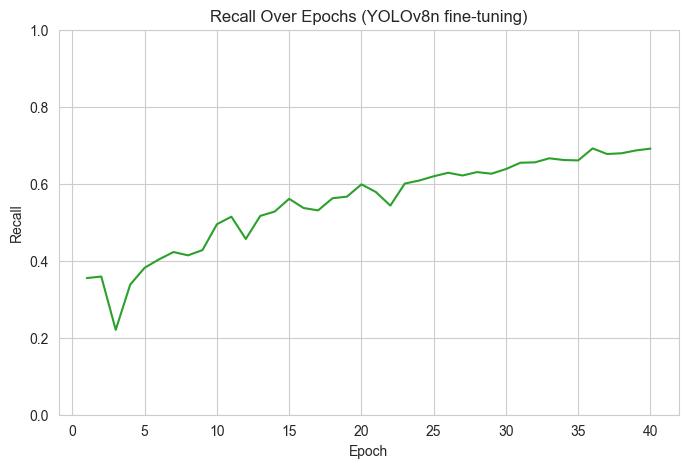

In [24]:
# Recall Curve
if history.empty or "metrics/recall(B)" not in history:
    print("Recall history is unavailable.")
else:
    plt.figure(figsize=(8, 5))
    plt.plot(history["epoch"], history["metrics/recall(B)"], color="tab:green")
    plt.xlabel("Epoch")
    plt.ylabel("Recall")
    plt.title("Recall Over Epochs (YOLOv8n fine-tuning)")
    plt.ylim(0, 1)
    plt.grid(True)
    plt.show()


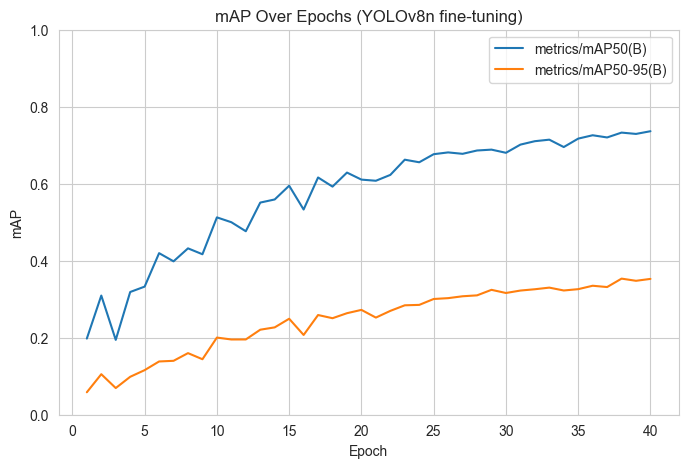

In [25]:
# mAP Curves
if history.empty:
    print("No history available.")
else:
    plt.figure(figsize=(8, 5))
    for col in ["metrics/mAP50(B)", "metrics/mAP50-95(B)"]:
        if col in history:
            plt.plot(history["epoch"], history[col], label=col)

    plt.xlabel("Epoch")
    plt.ylabel("mAP")
    plt.title("mAP Over Epochs (YOLOv8n fine-tuning)")
    plt.ylim(0, 1)
    plt.legend()
    plt.grid(True)
    plt.show()


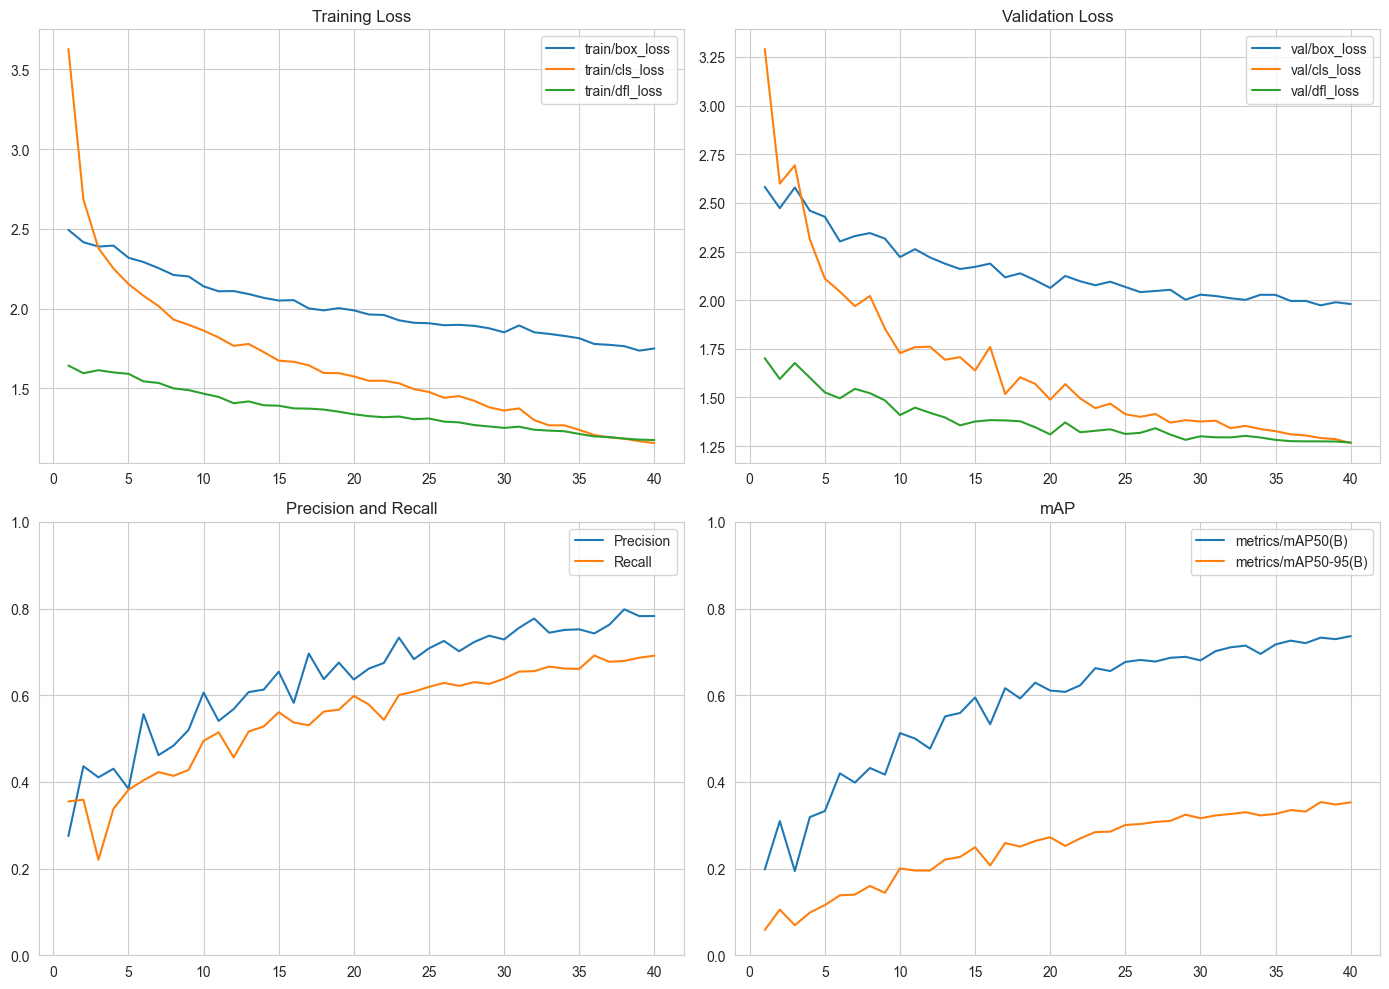

In [26]:
# Combined Training Dashboard
if history.empty:
    print("No history available.")
else:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    for col in loss_cols:
        if col in history:
            axes[0, 0].plot(history["epoch"], history[col], label=col)
    axes[0, 0].set_title("Training Loss")
    axes[0, 0].legend()
    axes[0, 0].grid(True)

    for col in val_loss_cols:
        if col in history:
            axes[0, 1].plot(history["epoch"], history[col], label=col)
    axes[0, 1].set_title("Validation Loss")
    axes[0, 1].legend()
    axes[0, 1].grid(True)

    if "metrics/precision(B)" in history:
        axes[1, 0].plot(history["epoch"], history["metrics/precision(B)"], label="Precision")
    if "metrics/recall(B)" in history:
        axes[1, 0].plot(history["epoch"], history["metrics/recall(B)"], label="Recall")
    axes[1, 0].set_title("Precision and Recall")
    axes[1, 0].set_ylim(0, 1)
    axes[1, 0].legend()
    axes[1, 0].grid(True)

    for col in ["metrics/mAP50(B)", "metrics/mAP50-95(B)"]:
        if col in history:
            axes[1, 1].plot(history["epoch"], history[col], label=col)
    axes[1, 1].set_title("mAP")
    axes[1, 1].set_ylim(0, 1)
    axes[1, 1].legend()
    axes[1, 1].grid(True)

    plt.tight_layout()
    plt.show()


[PosixPath('/content/results/training/pothole_training/confusion_matrix.png'), PosixPath('/content/results/training/pothole_training/confusion_matrix_normalized.png')]


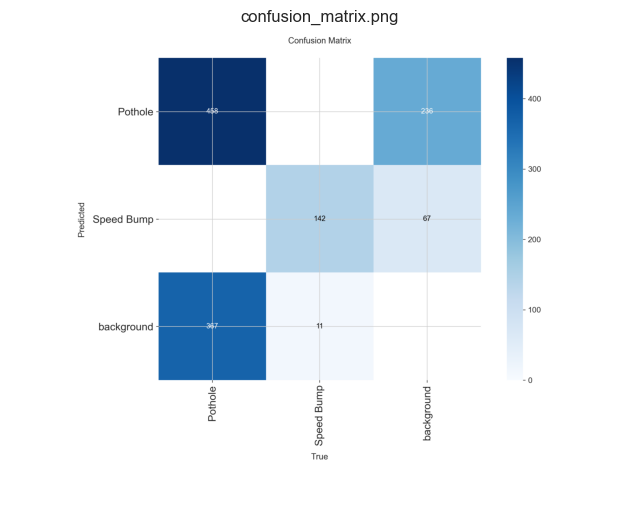

In [76]:
# Confusion Matrix (fine-tuned model)
train_dir = TRAIN_PROJECT / TRAIN_NAME

confusion_files = list(train_dir.glob("confusion_matrix*.png"))
print(confusion_files)

if confusion_files:
    img = Image.open(confusion_files[0])
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.title(confusion_files[0].name)
    plt.show()
else:
    print("No confusion matrix image found.")


[PosixPath('/content/results/training/pothole_training/BoxPR_curve.png')]


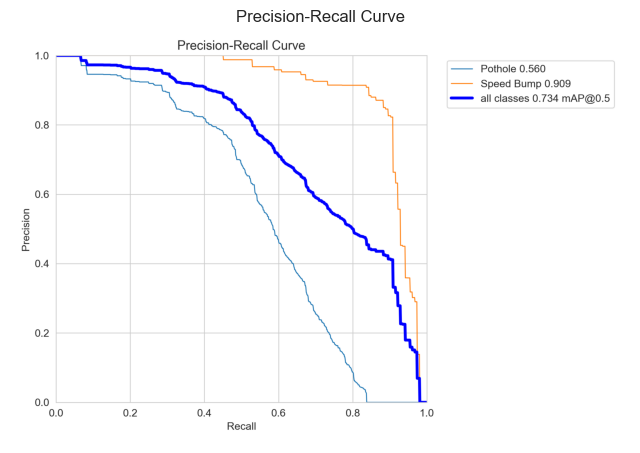

In [28]:
# Precision-Recall Curve (fine-tuned model)
pr_files = list(train_dir.glob("*PR_curve*.png"))
print(pr_files)

if pr_files:
    img = Image.open(pr_files[0])
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Precision-Recall Curve")
    plt.show()
else:
    print("No PR curve image found.")


[PosixPath('/content/results/training/pothole_training/BoxF1_curve.png')]


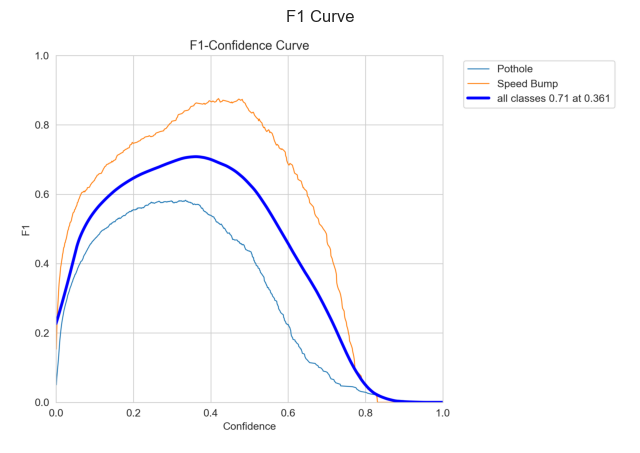

In [29]:
# F1 Curve (fine-tuned model)
f1_files = list(train_dir.glob("*F1_curve*.png"))
print(f1_files)

if f1_files:
    img = Image.open(f1_files[0])
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.title("F1 Curve")
    plt.show()
else:
    print("No F1 curve image found.")


[PosixPath('/content/results/training/pothole_training/BoxP_curve.png')]


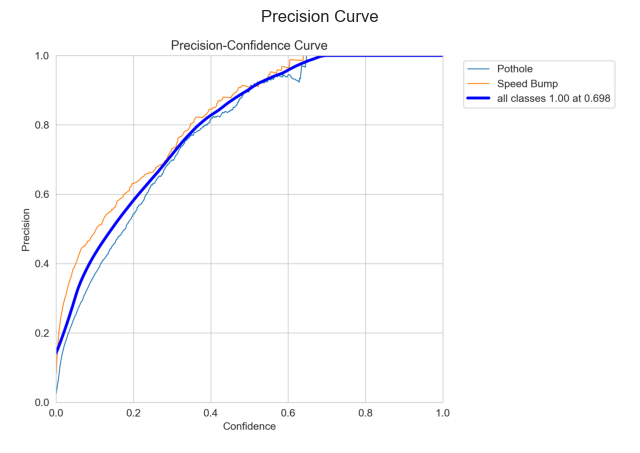

In [30]:
# Precision Curve, raw YOLO output (fine-tuned model)
precision_curve_files = list(train_dir.glob("*P_curve*.png"))
print(precision_curve_files)

if precision_curve_files:
    img = Image.open(precision_curve_files[0])
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Precision Curve")
    plt.show()
else:
    print("No precision curve image found.")


[PosixPath('/content/results/training/pothole_training/BoxR_curve.png'), PosixPath('/content/results/training/pothole_training/BoxPR_curve.png')]


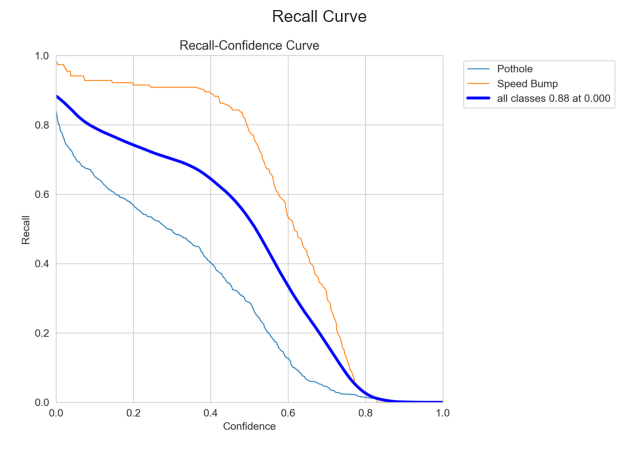

In [31]:
# Recall Curve, raw YOLO output (fine-tuned model)
recall_curve_files = list(train_dir.glob("*R_curve*.png"))
print(recall_curve_files)

if recall_curve_files:
    img = Image.open(recall_curve_files[0])
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Recall Curve")
    plt.show()
else:
    print("No recall curve image found.")
